# **DATA VISUALIZATION 2**
Data Visualization III Download the Iris flower dataset or any other dataset
into a DataFrame. (e.g., https://archive.ics.uci.edu/ml/datasets/Iris ). Scan
the dataset and give the inference as:
1. List down the features and their types (e.g., numeric, nominal) available
in the dataset.
2. Create a histogram for each feature in the dataset to illustrate the feature
distributions.
3. Create a boxplot for each feature in the dataset. 4. Compare distributions
and identify outliers
4. Compare distributions and identify outliers

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = sns.load_dataset('iris')
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


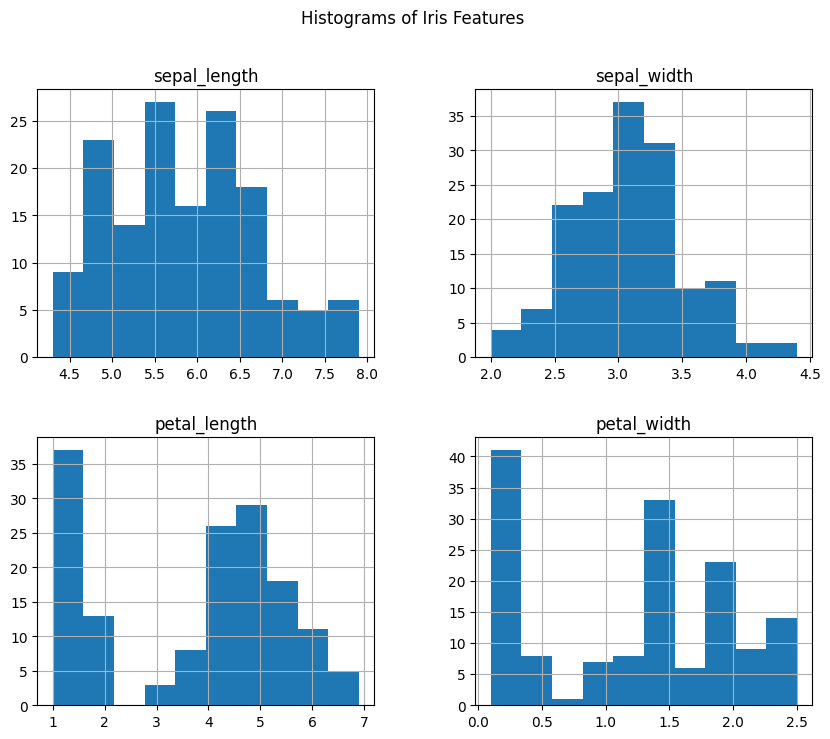

In [7]:
df.hist(figsize=(10, 8))
plt.suptitle("Histograms of Iris Features")
plt.show()

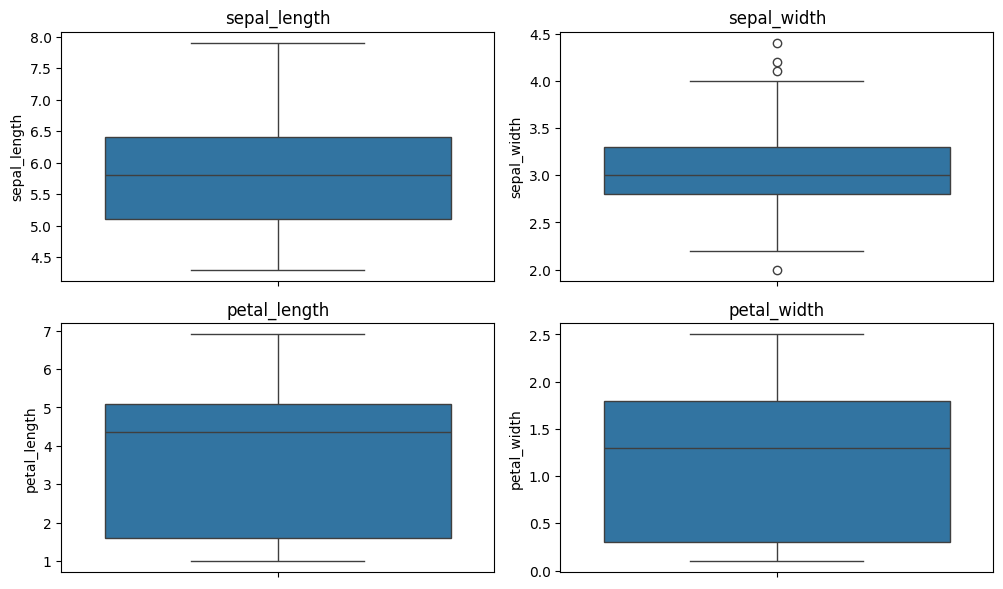

In [8]:
plt.figure(figsize=(10, 6))

for i, column in enumerate(df.columns[:-1], 1):
  plt.subplot(2, 2, i)
  sns.boxplot(y=df[column])
  plt.title(column)

plt.tight_layout()
plt.show()

In [9]:
# Copy dataset (safe practice)
df_clean = df.copy()

# Select only numeric columns
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns

# Remove outliers using IQR
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

# Check result
print("Original Shape:", df.shape)
print("After Removing Outliers:", df_clean.shape)

Original Shape: (150, 5)
After Removing Outliers: (146, 5)


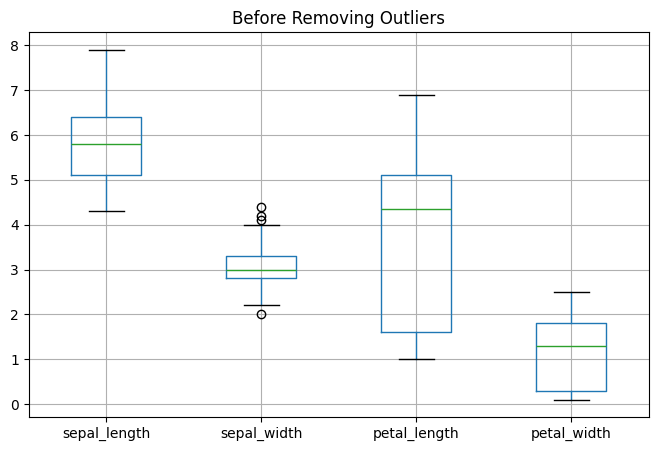

In [10]:
import matplotlib.pyplot as plt

df.boxplot(figsize=(8,5))
plt.title("Before Removing Outliers")
plt.show()

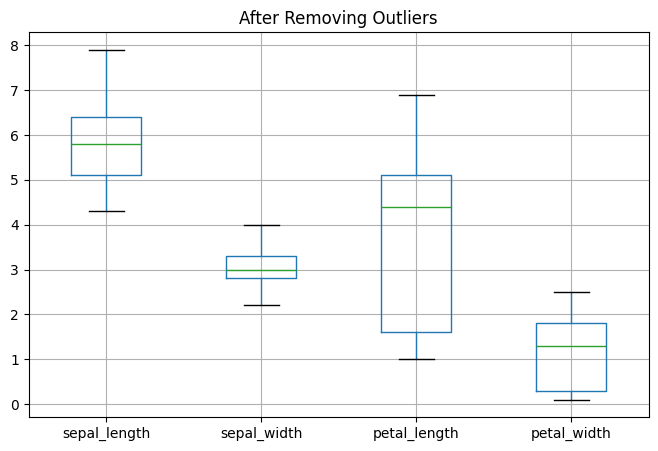

In [11]:
df_clean.boxplot(figsize=(8,5))
plt.title("After Removing Outliers")
plt.show()